In [19]:
import pandas as pd
from datetime import date, timedelta
import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from prophet import Prophet
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [20]:
df=pd.read_csv('Month_Value_1.csv')
df.head()

,Period,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
0,01.01.2015,1.601007e+07,12729.0,1257.763541,30024676.0
1,01.02.2015,1.580759e+07,11636.0,1358.507000,30024676.0
2,01.03.2015,2.204715e+07,15922.0,1384.697024,30024676.0
3,01.04.2015,1.881458e+07,15227.0,1235.606705,30024676.0
4,01.05.2015,1.402148e+07,8620.0,1626.621765,30024676.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    96 non-null     object 
 1   Revenue                                   64 non-null     float64
 2   Sales_quantity                            64 non-null     float64
 3   Average_cost                              64 non-null     float64
 4   The_average_annual_payroll_of_the_region  64 non-null     float64
dtypes: float64(4), object(1)
memory usage: 3.9+ KB


In [22]:
df.isnull().sum()

Period                                       0
Revenue                                     32
Sales_quantity                              32
Average_cost                                32
The_average_annual_payroll_of_the_region    32
dtype: int64

In [23]:
df.describe()

,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
count,6.400000e+01,64.000000,64.000000,6.400000e+01
mean,3.236045e+07,19197.375000,1695.061159,2.869083e+07
std,1.164150e+07,6591.287257,296.844793,1.057191e+06
min,1.402148e+07,8314.000000,1110.576805,2.740647e+07
25%,2.242655e+07,15065.500000,1499.142841,2.782857e+07
50%,3.209088e+07,18368.000000,1654.399798,2.819785e+07
75%,3.992999e+07,22856.250000,1916.401096,2.987852e+07
max,5.875647e+07,38069.000000,2559.328184,3.002468e+07


In [24]:
df.columns = ['Period', 'Revenue', 'sales', 'avg_cost', 'avg_employees']

df["Period"] = pd.to_datetime(df["Period"], format="%d.%m.%Y", errors="coerce")
df = df.sort_values("Period")
df = df.set_index("Period")
df = df.dropna(subset=["Revenue"])
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
df.describe()

,Revenue,sales,avg_cost,avg_employees
count,6.400000e+01,64.000000,64.000000,6.400000e+01
mean,3.236045e+07,19197.375000,1695.061159,2.869083e+07
std,1.164150e+07,6591.287257,296.844793,1.057191e+06
min,1.402148e+07,8314.000000,1110.576805,2.740647e+07
25%,2.242655e+07,15065.500000,1499.142841,2.782857e+07
50%,3.209088e+07,18368.000000,1654.399798,2.819785e+07
75%,3.992999e+07,22856.250000,1916.401096,2.987852e+07
max,5.875647e+07,38069.000000,2559.328184,3.002468e+07


In [25]:
df.isnull().sum()

Revenue          0
sales            0
avg_cost         0
avg_employees    0
dtype: int64

In [26]:
ts = df["Revenue"]
ts.index = ts.index.to_period("M").to_timestamp("M")
ts = ts.asfreq("ME").interpolate(method="time")

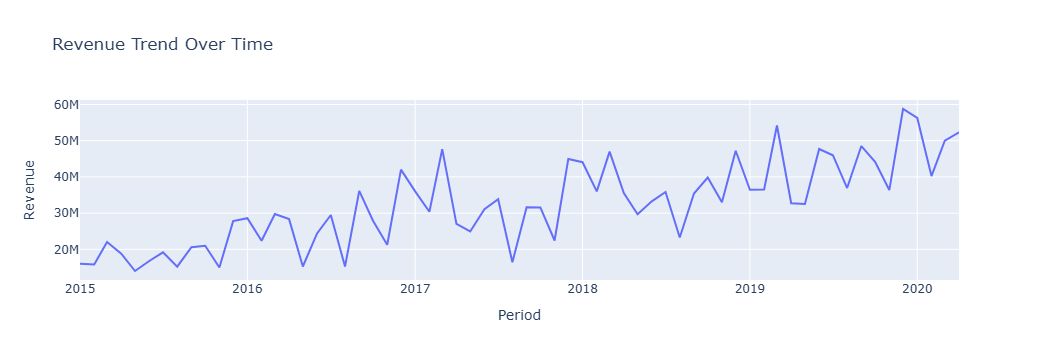

In [27]:
px.line(df, x=df.index, y="Revenue", title="Revenue Trend Over Time")

<Figure size 1500x1000 with 0 Axes>

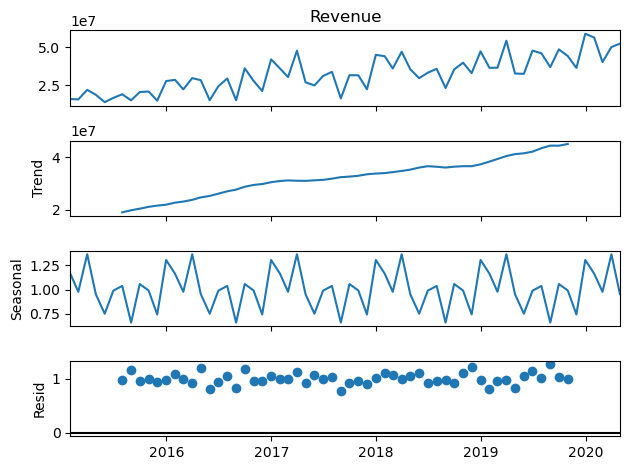

In [28]:
plt.figure(figsize=(15,10)) 
result = seasonal_decompose(ts, model='multiplicative', period=12)
result.plot()
plt.show()

In [29]:
train = ts.iloc[:-12]
test = ts.iloc[-12:]

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

Размер обучающей выборки: 52
Размер тестовой выборки: 12


In [30]:
model_sarima = sm.tsa.statespace.SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarima = model_sarima.fit()
print(result_sarima.summary())

sarima_pred = result_sarima.predict(start=test.index[0], end=test.index[-1])

mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))
mape_sarima = np.mean(np.abs((test - sarima_pred) / test)) * 100

print(f"SARIMA - MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2f}%")

                                     SARIMAX Results                                      
Dep. Variable:                            Revenue   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -421.154
Date:                            Sun, 15 Mar 2026   AIC                            852.309
Time:                                    23:56:38   BIC                            858.403
Sample:                                01-31-2015   HQIC                           853.999
                                     - 04-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0338      0.489      0.069      0.945      -0.924       0.992
ma.L1         -0.6975      0.417   

In [31]:
model_arima = ARIMA(train, order=(5,1,0))
result_arima = model_arima.fit()
print(result_arima.summary())

arima_pred = result_arima.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))
mape_arima = np.mean(np.abs((test - arima_pred) / test)) * 100

print(f"ARIMA - MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}%")

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                   52
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -870.415
Date:                Sun, 15 Mar 2026   AIC                           1752.831
Time:                        23:56:39   BIC                           1764.422
Sample:                    01-31-2015   HQIC                          1757.260
                         - 04-30-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5693      0.116     -4.912      0.000      -0.796      -0.342
ar.L2         -0.1781      0.138     -1.293      0.196      -0.448       0.092
ar.L3          0.2630      0.149      1.763      0.0

In [32]:
model_hw = ExponentialSmoothing(
    train,
    seasonal_periods=12,
    trend='add',
    seasonal='add',
    initialization_method='estimated'
)
result_hw = model_hw.fit()
print(result_hw.summary())

hw_pred = result_hw.forecast(len(test))

mae_hw = mean_absolute_error(test, hw_pred)
rmse_hw = np.sqrt(mean_squared_error(test, hw_pred))
mape_hw = np.mean(np.abs((test - hw_pred) / test)) * 100

print(f"Holt-Winters - MAE: {mae_hw:.2f}, RMSE: {rmse_hw:.2f}, MAPE: {mape_hw:.2f}%")

                        ExponentialSmoothing Model Results                       
Dep. Variable:                  Revenue   No. Observations:                    52
Model:             ExponentialSmoothing   SSE                 755763459201777.000
Optimized:                         True   AIC                            1607.990
Trend:                         Additive   BIC                            1639.210
Seasonal:                      Additive   AICC                           1628.718
Seasonal Periods:                    12   Date:                  Sun, 15 Mar 2026
Box-Cox:                          False   Time:                          23:56:39
Box-Cox Coeff.:                    None                                          
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1817857                alpha                 True
smoothing_trend 

In [33]:
def create_features(series, n_lags=12):
    df_features = pd.DataFrame({'target': series})
    for i in range(1, n_lags+1):
        df_features[f'lag_{i}'] = series.shift(i)
    df_features['month'] = series.index.month
    df_features['quarter'] = series.index.quarter
    df_features['year'] = series.index.year
    return df_features.dropna()

df_features = create_features(ts, n_lags=12)

X = df_features.drop('target', axis=1)
y = df_features['target']

X_train = X[X.index.isin(train.index[train.index.isin(X.index)])]
X_test = X[X.index.isin(test.index[test.index.isin(X.index)])]
y_train = y[y.index.isin(train.index[train.index.isin(y.index)])]
y_test = y[y.index.isin(test.index[test.index.isin(y.index)])]

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
mape_lr = np.mean(np.abs((y_test - lr_pred) / y_test)) * 100

print(f"Linear Regression - MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, MAPE: {mape_lr:.2f}%")

Linear Regression - MAE: 7741904.15, RMSE: 9118112.71, MAPE: 16.54%


In [34]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mape_rf = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, MAPE: {mape_rf:.2f}%")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nВажность признаков (Random Forest):")
print(feature_importance.head(10))

Random Forest - MAE: 9470404.98, RMSE: 10997997.44, MAPE: 19.32%

Важность признаков (Random Forest):
   feature  importance
11  lag_12    0.659709
3    lag_4    0.060632
8    lag_9    0.053180
6    lag_7    0.048609
2    lag_3    0.041671
5    lag_6    0.028765
1    lag_2    0.017187
9   lag_10    0.016286
7    lag_8    0.015161
4    lag_5    0.015017


In [35]:
xgb = XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print(f"XGBoost - MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, MAPE: {mape_xgb:.2f}%")

XGBoost - MAE: 8527035.04, RMSE: 10306483.87, MAPE: 17.62%


In [36]:
results_df = pd.DataFrame({
    'Actual': test.values
}, index=test.index)

results_df['SARIMA'] = sarima_pred.values
results_df['ARIMA'] = arima_pred
results_df['Holt-Winters'] = hw_pred.values

if len(X_test) == len(test):
    results_df['Linear Regression'] = lr_pred
    results_df['Random Forest'] = rf_pred
    results_df['XGBoost'] = xgb_pred

metrics = pd.DataFrame({
    'Model': ['SARIMA', 'ARIMA', 'Holt-Winters', 'Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_sarima, mae_arima, mae_hw, mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_sarima, rmse_arima, rmse_hw, rmse_lr, rmse_rf, rmse_xgb],
    'MAPE': [mape_sarima, mape_arima, mape_hw, mape_lr, mape_rf, mape_xgb]
})

metrics = metrics.sort_values('MAE').reset_index(drop=True)
print("\nМетрики моделей (отсортированы по MAE):")
print(metrics.to_string(index=False))


Метрики моделей (отсортированы по MAE):
            Model          MAE         RMSE      MAPE
     Holt-Winters 6.242329e+06 6.954531e+06 13.362175
Linear Regression 7.741904e+06 9.118113e+06 16.537362
           SARIMA 8.144048e+06 9.402618e+06 17.301875
            ARIMA 8.322559e+06 1.073359e+07 17.240395
          XGBoost 8.527035e+06 1.030648e+07 17.617163
    Random Forest 9.470405e+06 1.099800e+07 19.322735


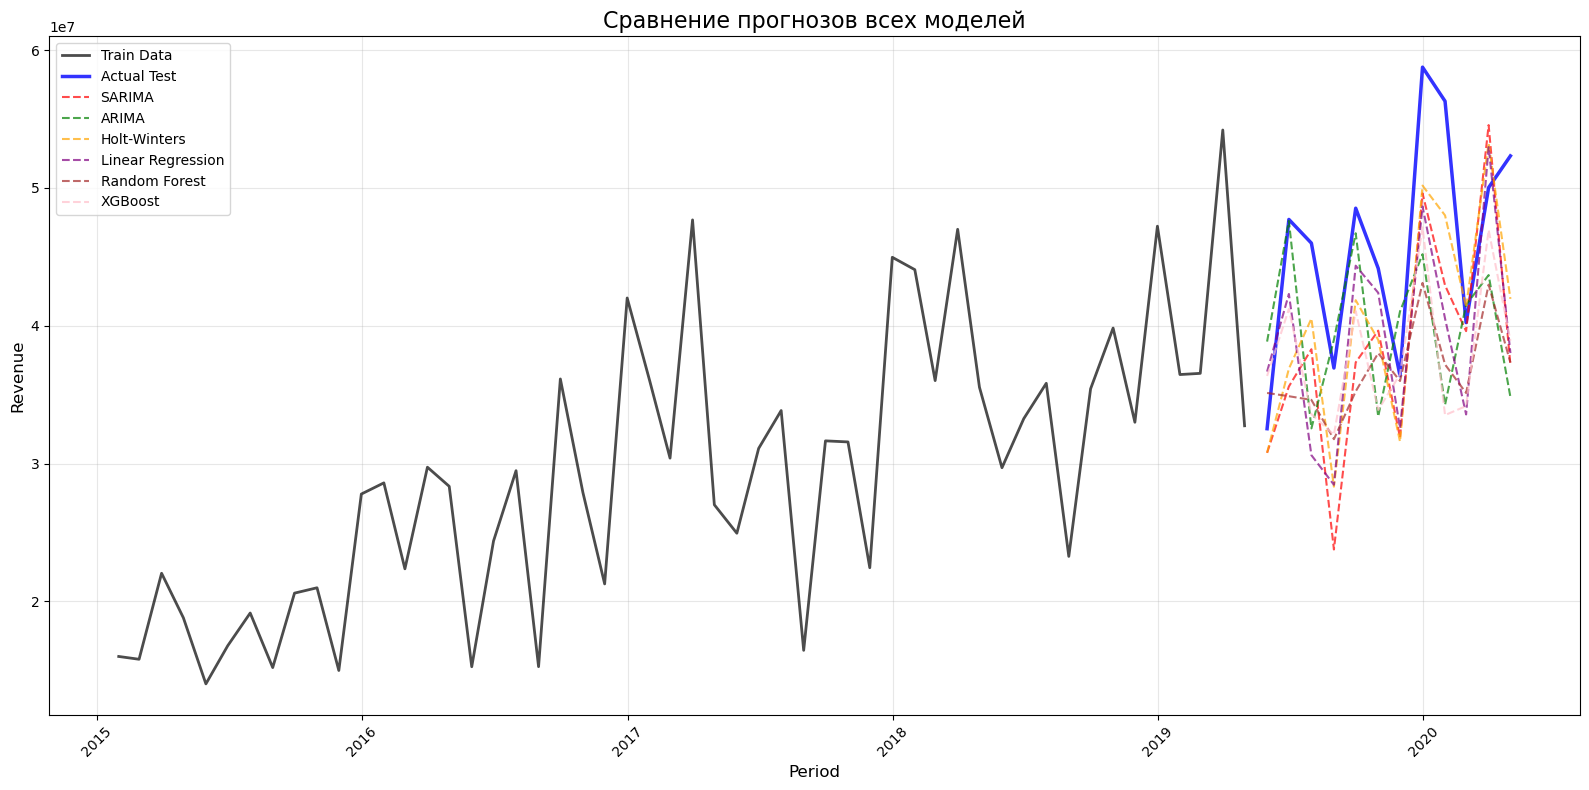

In [37]:
plt.figure(figsize=(16, 8))
plt.plot(train.index, train, 'k-', linewidth=2, label='Train Data', alpha=0.7)
plt.plot(test.index, test, 'b-', linewidth=2.5, label='Actual Test', alpha=0.8)

colors = ['red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
for i, col in enumerate(results_df.columns[1:]):
    if col in results_df.columns:
        plt.plot(results_df.index, results_df[col], '--', linewidth=1.5, 
                color=colors[i % len(colors)], label=col, alpha=0.7)

plt.title('Сравнение прогнозов всех моделей', fontsize=16)
plt.xlabel('Period', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Отображаем 6 моделей:


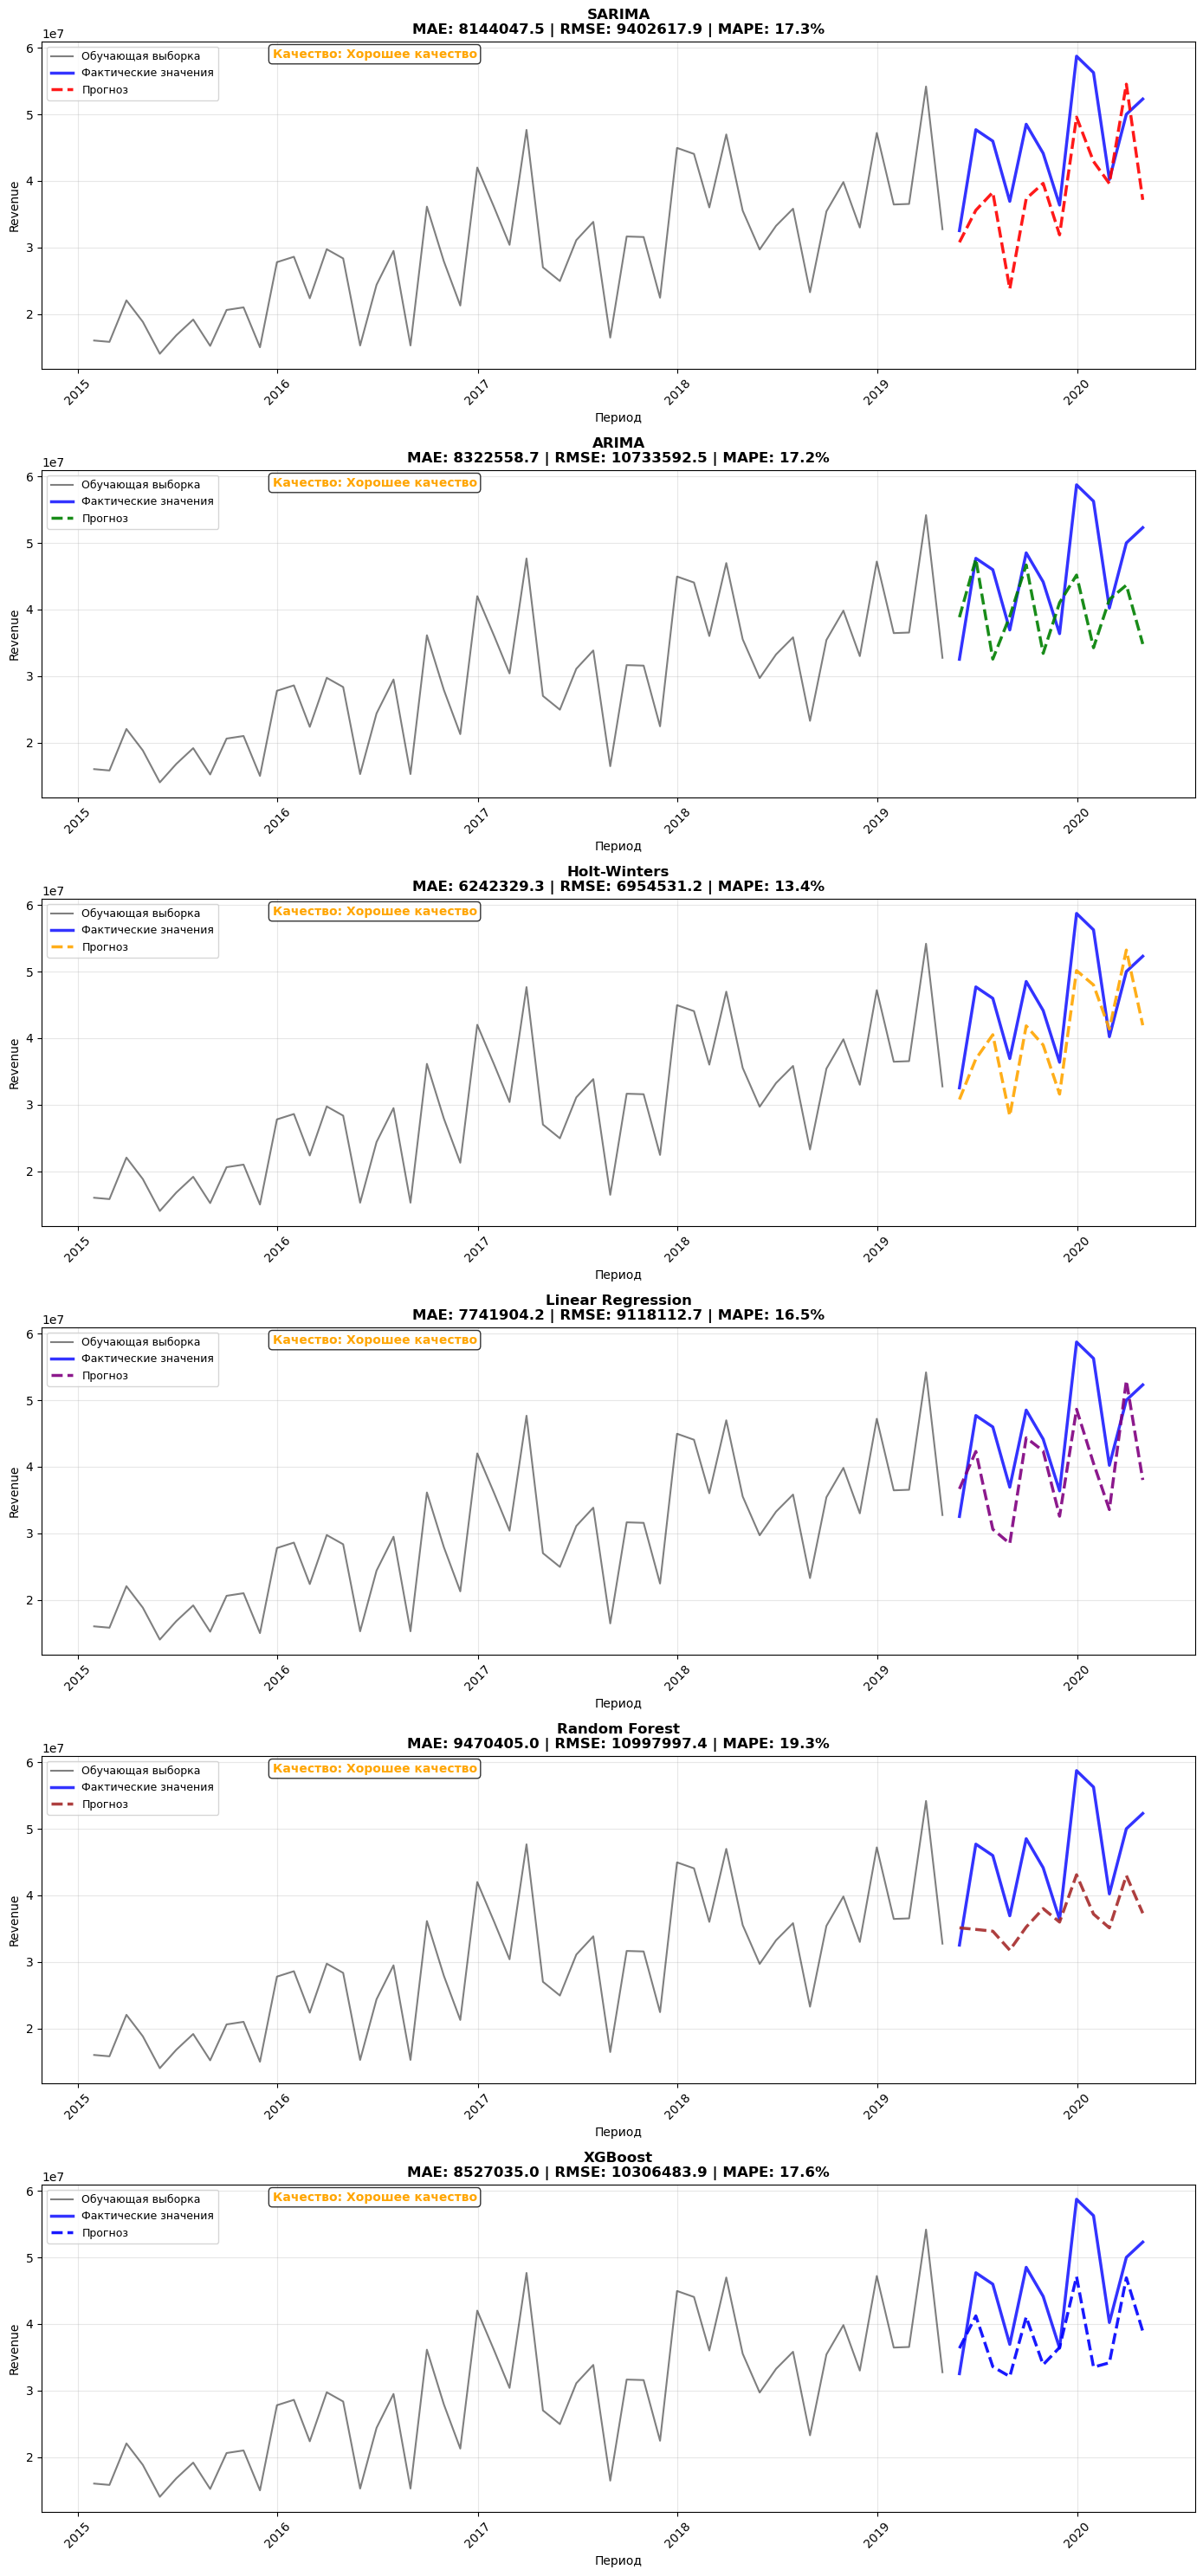

In [38]:
model_names = ['SARIMA', 'ARIMA', 'Holt-Winters', 'Linear Regression', 'Random Forest', 'XGBoost']
model_names = [m for m in model_names if m in results_df.columns]

n_models = len(model_names)
print(f"Отображаем {n_models} моделей:")

fig, axes = plt.subplots(n_models, 1, figsize=(14, 5 * n_models))
fig.suptitle('', fontsize=16, y=0.98)

colors = ['red', 'green', 'orange', 'purple', 'brown', 'blue']

for idx, model_name in enumerate(model_names):
    ax = axes[idx] if n_models > 1 else axes
    
    ax.plot(train.index, train, 'k-', linewidth=1.5, label='Обучающая выборка', alpha=0.5)
    
    ax.plot(test.index, test, 'b-', linewidth=2.5, label='Фактические значения', alpha=0.8)
    
    ax.plot(results_df.index, results_df[model_name], '--', 
            linewidth=2.5, color=colors[idx % len(colors)], 
            label=f'Прогноз', alpha=0.9)
    
    mae_val = metrics[metrics['Model'] == model_name]['MAE'].values[0]
    rmse_val = metrics[metrics['Model'] == model_name]['RMSE'].values[0]
    mape_val = metrics[metrics['Model'] == model_name]['MAPE'].values[0]
    
    ax.set_title(f'{model_name}\nMAE: {mae_val:.1f} | RMSE: {rmse_val:.1f} | MAPE: {mape_val:.1f}%', 
                fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Период', fontsize=10)
    ax.set_ylabel('Revenue', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    if mape_val < 10:
        quality = "Отличное качество"
        quality_color = "green"
    elif mape_val < 20:
        quality = "Хорошее качество"
        quality_color = "orange"
    else:
        quality = "Плохое качество"
        quality_color = "red"
    
    ax.text(0.2, 0.95, f"Качество: {quality}", 
            transform=ax.transAxes, fontsize=10, 
            color=quality_color, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

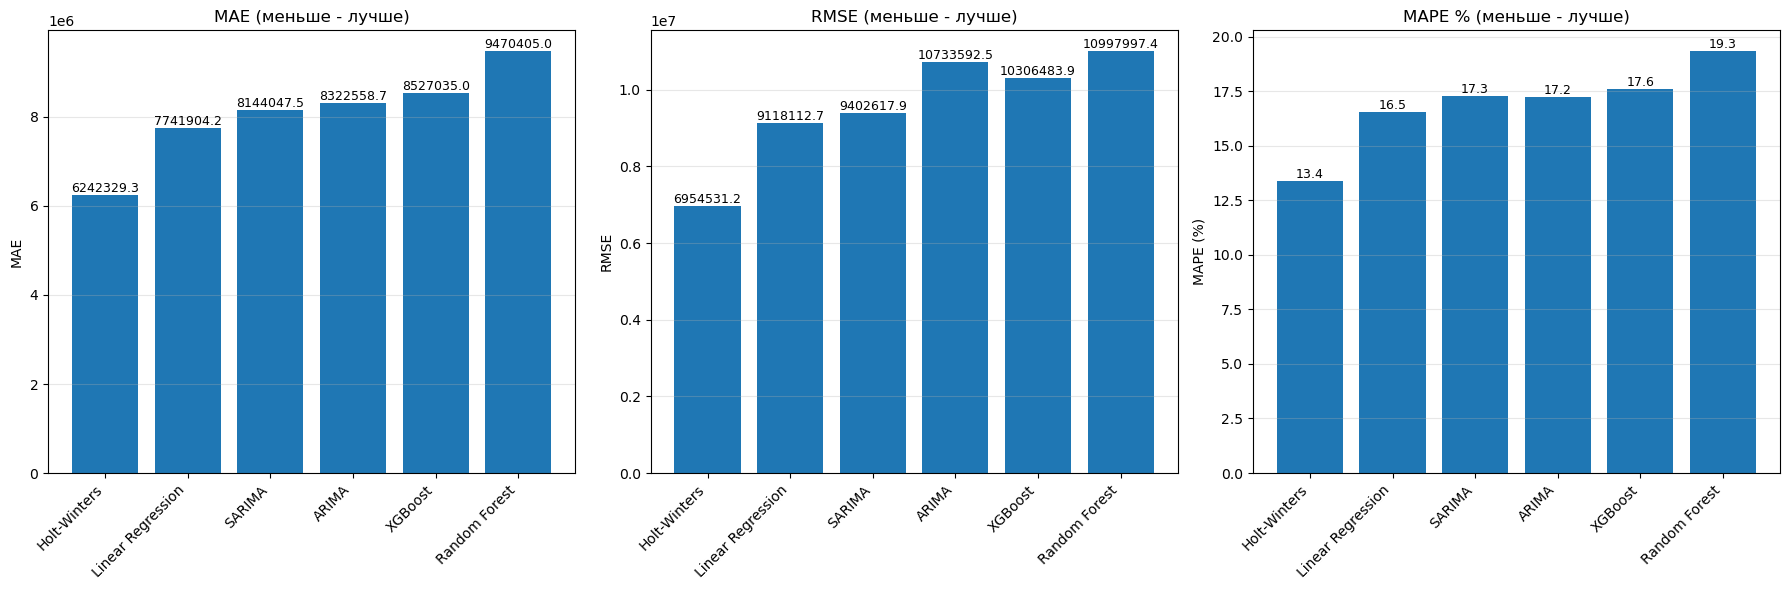

In [39]:
ig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Сравнение метрик моделей', fontsize=16)

bars1 = axes[0].bar(range(len(metrics)), metrics['MAE'].values)
axes[0].set_xticks(range(len(metrics)))
axes[0].set_xticklabels(metrics['Model'].values, rotation=45, ha='right')
axes[0].set_title('MAE (меньше - лучше)')
axes[0].set_ylabel('MAE')
axes[0].grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(range(len(metrics)), metrics['RMSE'].values)
axes[1].set_xticks(range(len(metrics)))
axes[1].set_xticklabels(metrics['Model'].values, rotation=45, ha='right')
axes[1].set_title('RMSE (меньше - лучше)')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

bars3 = axes[2].bar(range(len(metrics)), metrics['MAPE'].values)
axes[2].set_xticks(range(len(metrics)))
axes[2].set_xticklabels(metrics['Model'].values, rotation=45, ha='right')
axes[2].set_title('MAPE % (меньше - лучше)')
axes[2].set_ylabel('MAPE (%)')
axes[2].grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars3):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



Лучшая модель по MAE: Holt-Winters


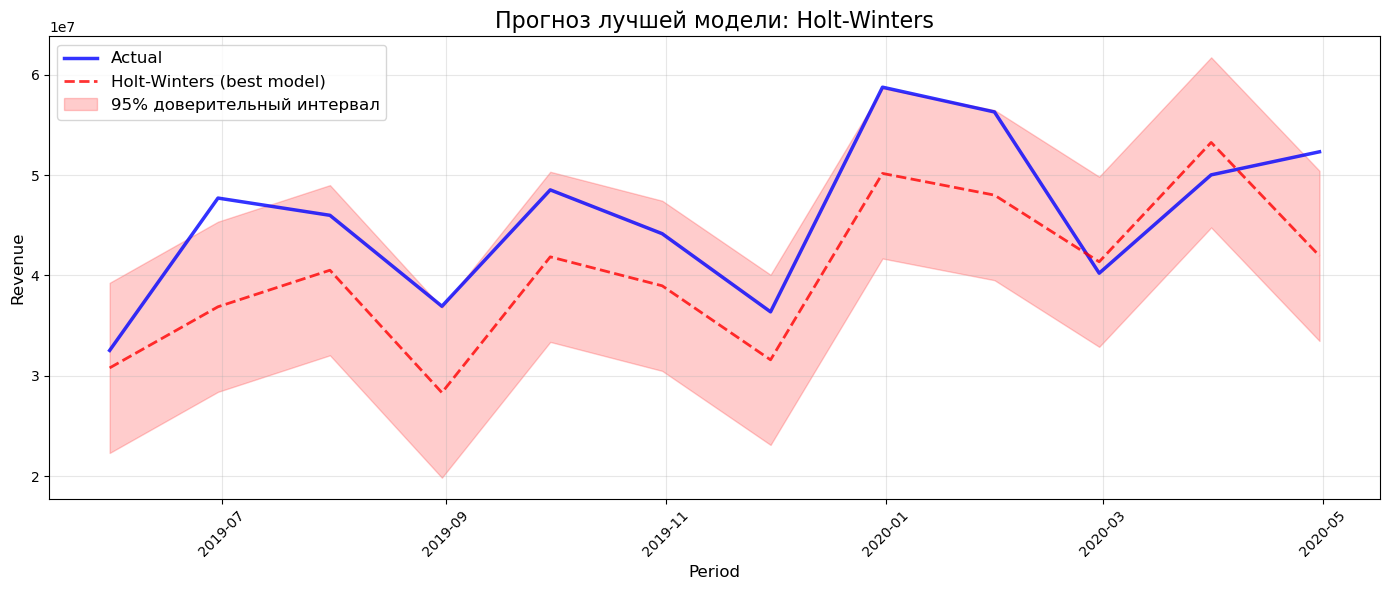

In [40]:
best_model = metrics.iloc[0]['Model']
print(f"\nЛучшая модель по MAE: {best_model}")

plt.figure(figsize=(14, 6))
plt.plot(test.index, test, 'b-', linewidth=2.5, label='Actual', alpha=0.8)
plt.plot(test.index, results_df[best_model], 'r--', linewidth=2, label=f'{best_model} (best model)', alpha=0.8)

if best_model in results_df.columns:
    errors = test.values - results_df[best_model].values
    error_std = np.std(errors)
    plt.fill_between(test.index, 
                     results_df[best_model] - 2*error_std,
                     results_df[best_model] + 2*error_std,
                     color='red', alpha=0.2, label='95% доверительный интервал')

plt.title(f'Прогноз лучшей модели: {best_model}', fontsize=16)
plt.xlabel('Period', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

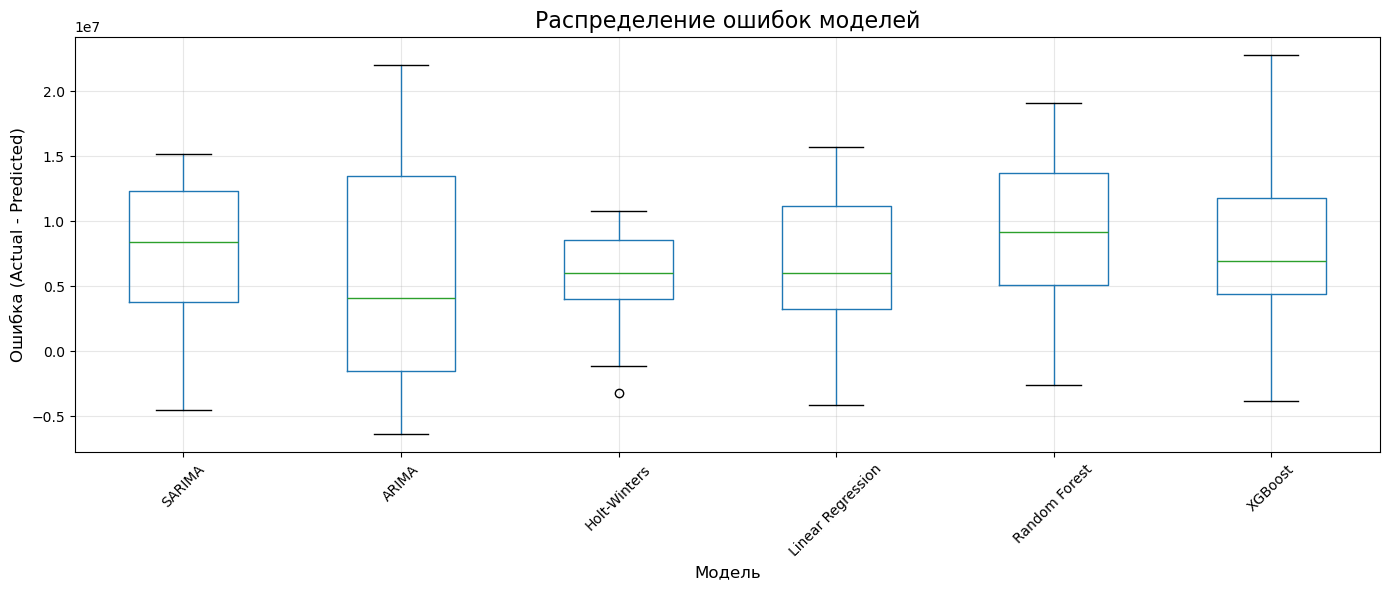

In [41]:
errors_df = pd.DataFrame()
for col in results_df.columns[1:]:
    if col in results_df.columns:
        errors_df[col] = results_df['Actual'] - results_df[col]

plt.figure(figsize=(14, 6))
errors_df.boxplot()
plt.title('Распределение ошибок моделей', fontsize=16)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Ошибка (Actual - Predicted)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
print(f"1. Лучшая модель по метрикам: {best_model}")
print(f"   MAE: {metrics.iloc[0]['MAE']:.2f}")
print(f"   RMSE: {metrics.iloc[0]['RMSE']:.2f}")
print(f"   MAPE: {metrics.iloc[0]['MAPE']:.2f}%")
print(f"\n2. Худшая модель по метрикам: {metrics.iloc[-1]['Model']}")
print(f"   MAE: {metrics.iloc[-1]['MAE']:.2f}")
print(f"   RMSE: {metrics.iloc[-1]['RMSE']:.2f}")
print(f"   MAPE: {metrics.iloc[-1]['MAPE']:.2f}%")

1. Лучшая модель по метрикам: Holt-Winters
   MAE: 6242329.29
   RMSE: 6954531.21
   MAPE: 13.36%

2. Худшая модель по метрикам: Random Forest
   MAE: 9470404.98
   RMSE: 10997997.44
   MAPE: 19.32%


In [43]:
residuals_dict = {}
for model_name in model_names:
    if model_name in results_df.columns:
        residuals_dict[model_name] = results_df['Actual'] - results_df[model_name]

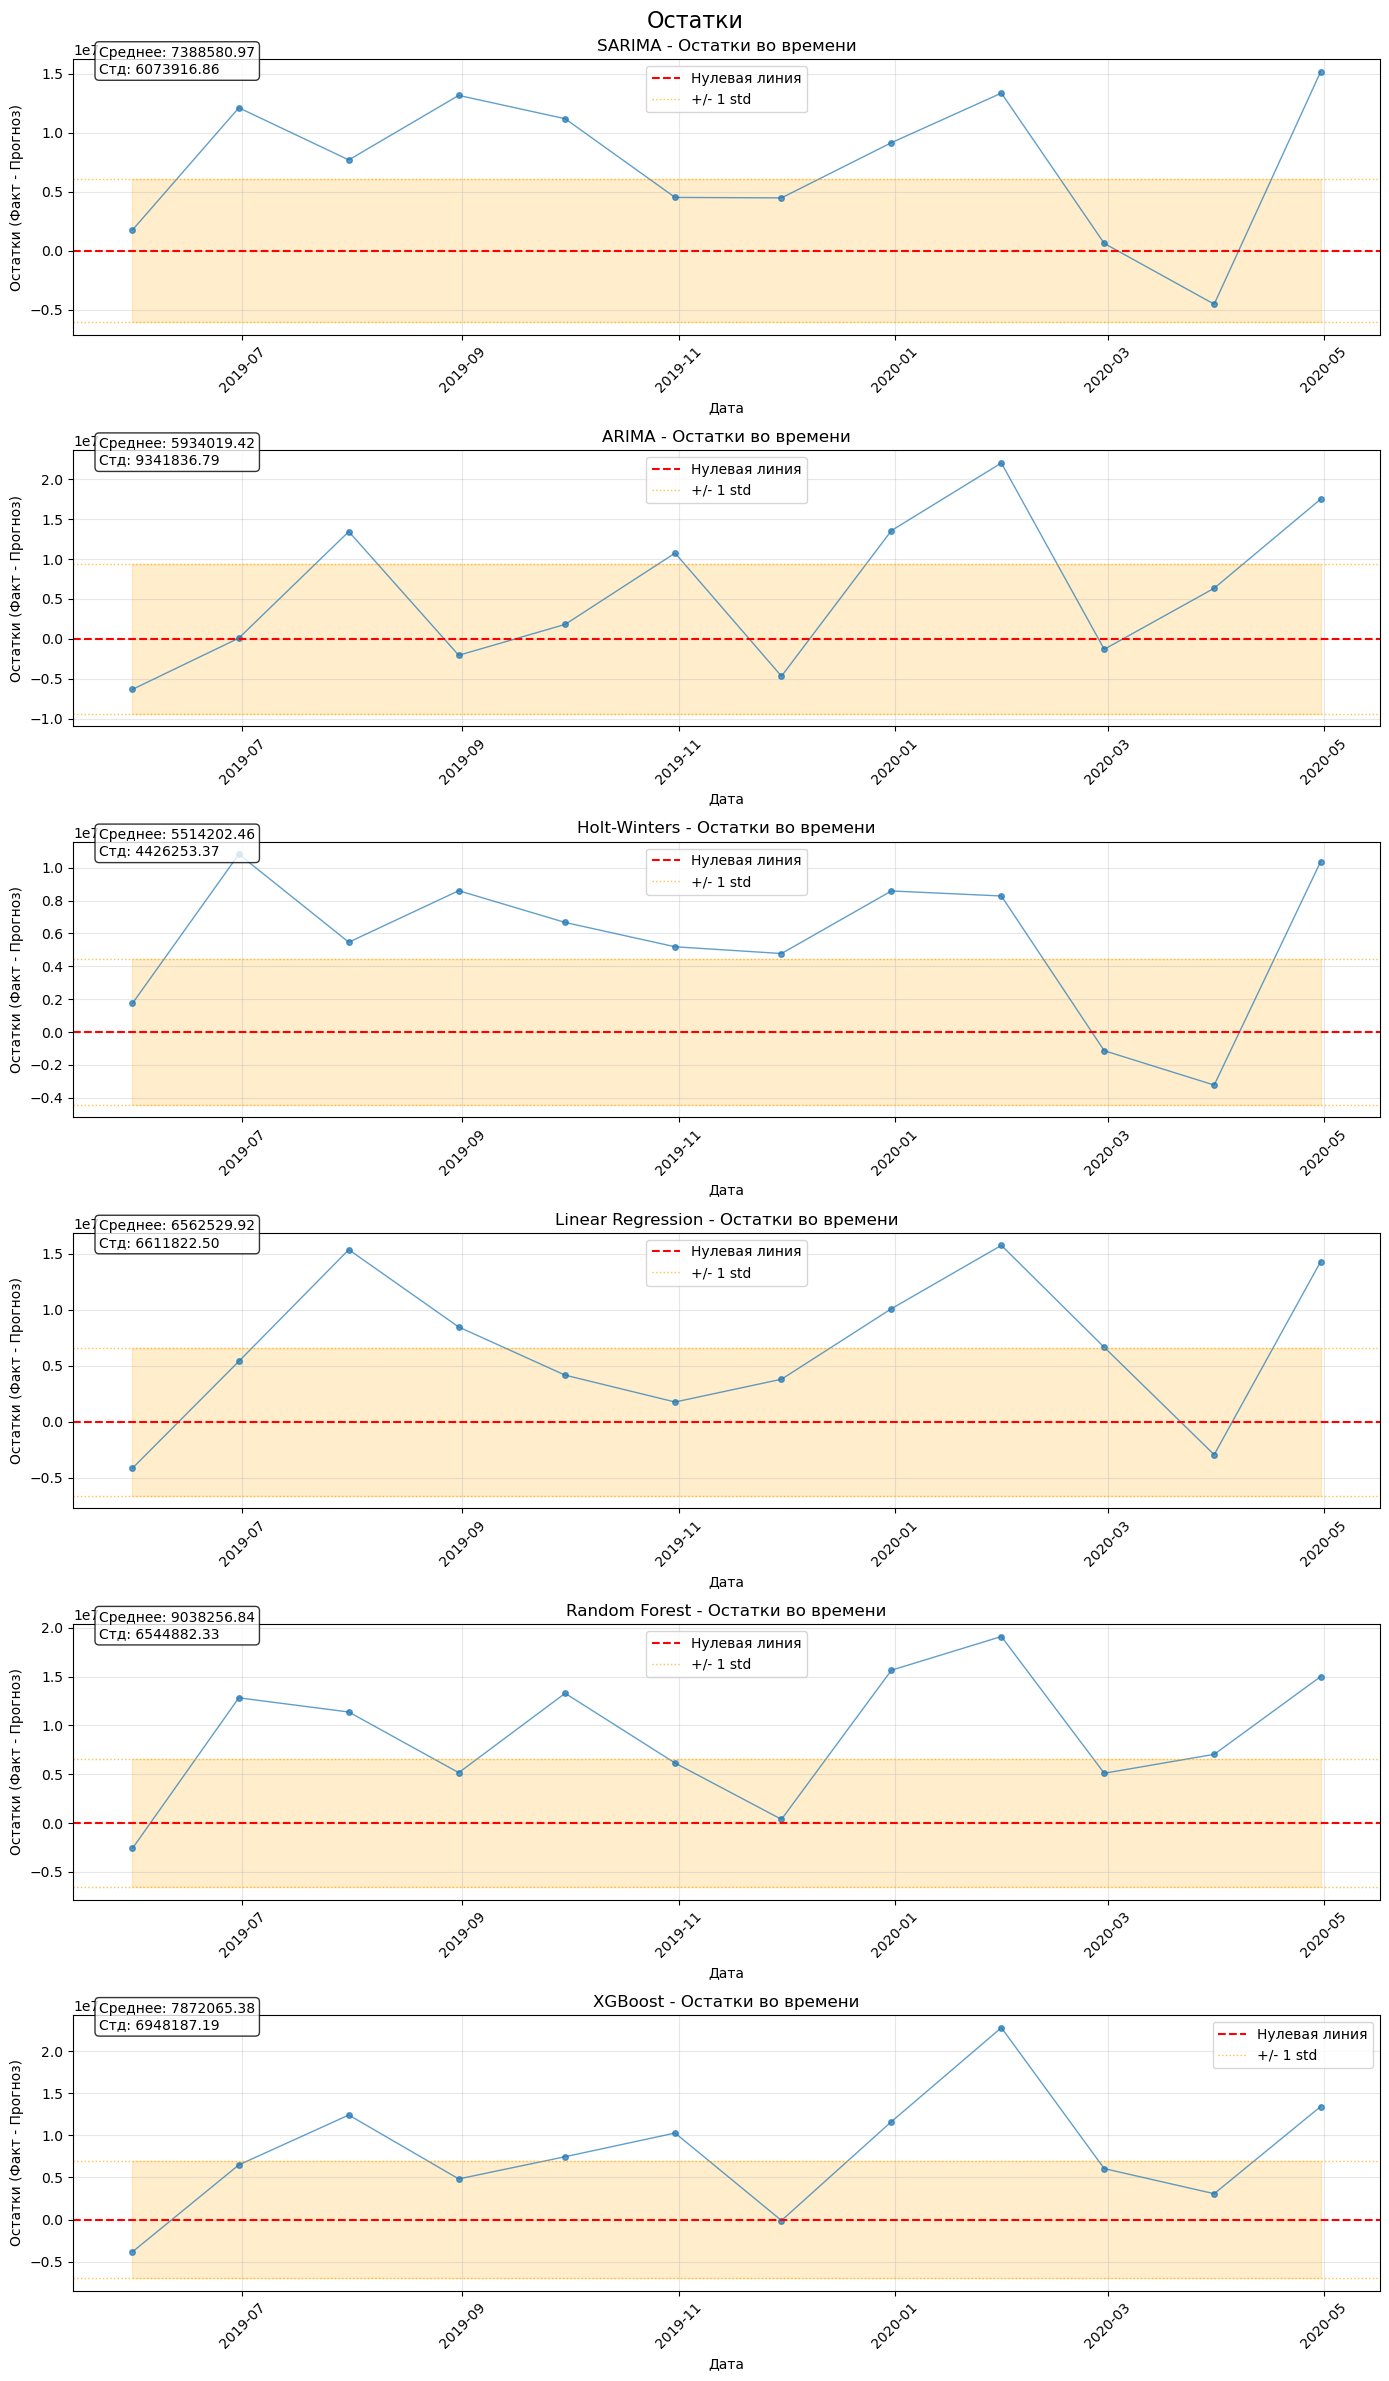

In [47]:
fig, axes = plt.subplots(len(model_names), 1, figsize=(14, 4 * len(model_names)))
fig.suptitle('Остатки', fontsize=16, y=0.99)

for idx, model_name in enumerate(model_names):
    ax = axes[idx] if len(model_names) > 1 else axes
    residuals = residuals_dict[model_name]
    
    ax.plot(residuals.index, residuals.values, 'o-', markersize=4, linewidth=1, alpha=0.7)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1.5, label='Нулевая линия')
    ax.axhline(y=residuals.std(), color='orange', linestyle=':', linewidth=1, alpha=0.7, label='+/- 1 std')
    ax.axhline(y=-residuals.std(), color='orange', linestyle=':', linewidth=1, alpha=0.7)
    ax.fill_between(residuals.index, -residuals.std(), residuals.std(), alpha=0.2, color='orange')
    
    ax.set_title(f'{model_name} - Остатки во времени')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Остатки (Факт - Прогноз)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    mean_resid = residuals.mean()
    std_resid = residuals.std()
    ax.text(0.02, 0.95, f'Среднее: {mean_resid:.2f}\nСтд: {std_resid:.2f}', 
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

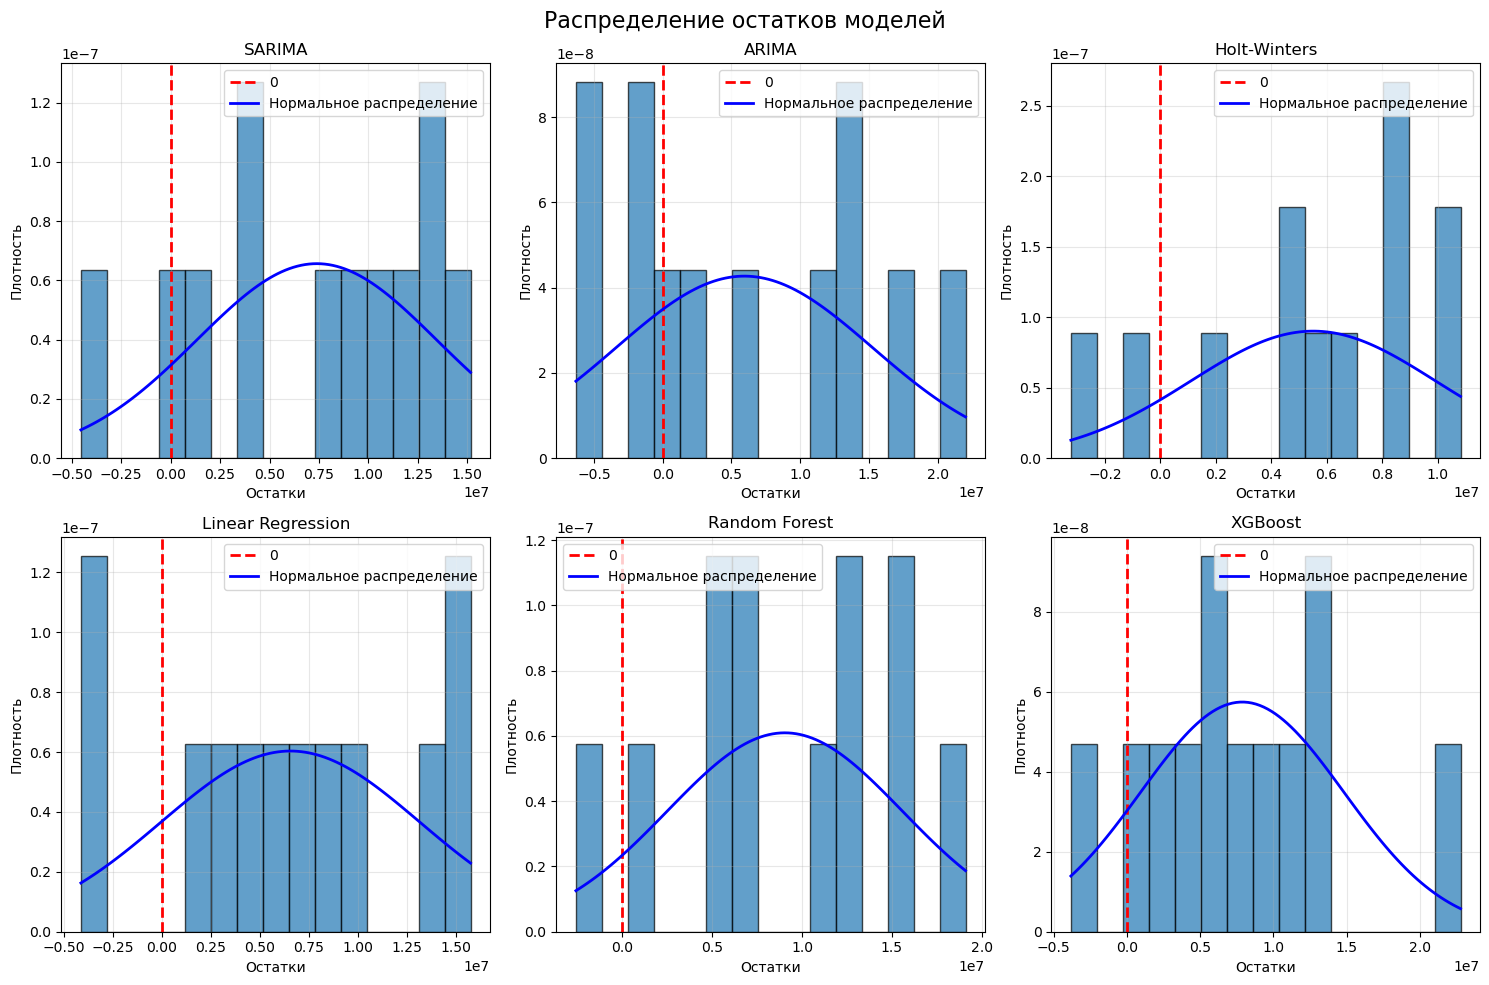

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение остатков моделей', fontsize=16)

for idx, model_name in enumerate(model_names):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    residuals = residuals_dict[model_name]
    
    # Гистограмма
    ax.hist(residuals, bins=15, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='0')
    
    # Нормальное распределение для сравнения
    from scipy.stats import norm
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax.plot(x, norm.pdf(x, residuals.mean(), residuals.std()), 
            'b-', linewidth=2, label='Нормальное распределение')
    
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Остатки')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

for idx in range(len(model_names), 6):
    row = idx // 3
    col = idx % 3
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()


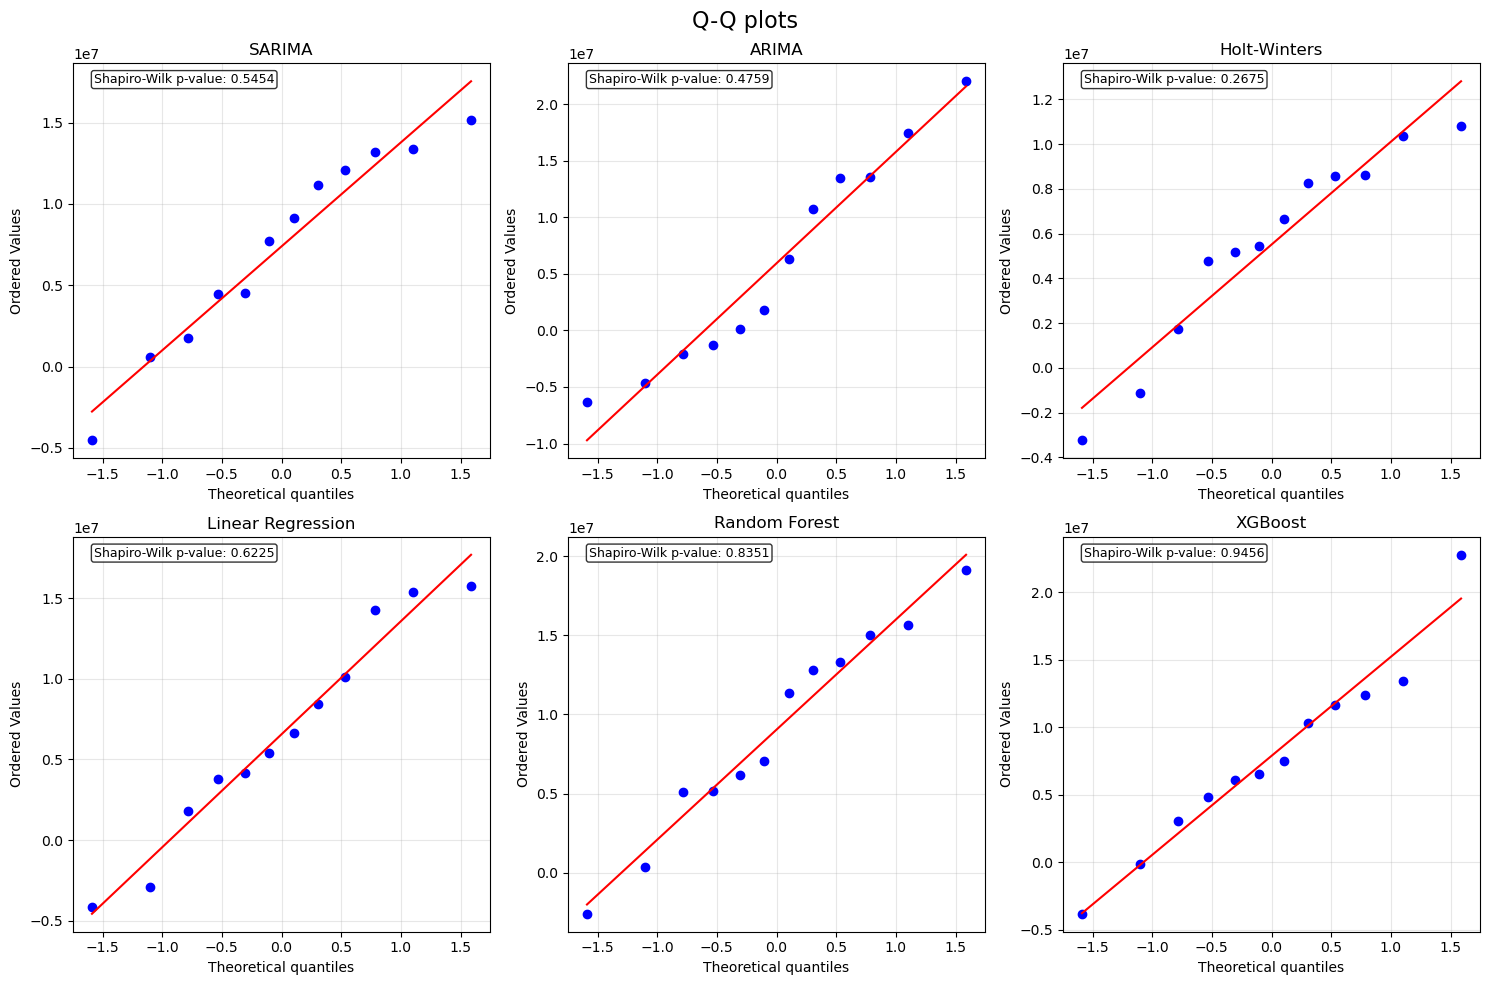

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Q-Q plots', fontsize=16)

from scipy import stats

for idx, model_name in enumerate(model_names):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    residuals = residuals_dict[model_name]
    
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f'{model_name}')
    ax.grid(True, alpha=0.3)

    if len(residuals) < 5000: 
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
        ax.text(0.05, 0.95, f'Shapiro-Wilk p-value: {shapiro_p:.4f}', 
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

for idx in range(len(model_names), 6):
    row = idx // 3
    col = idx % 3
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

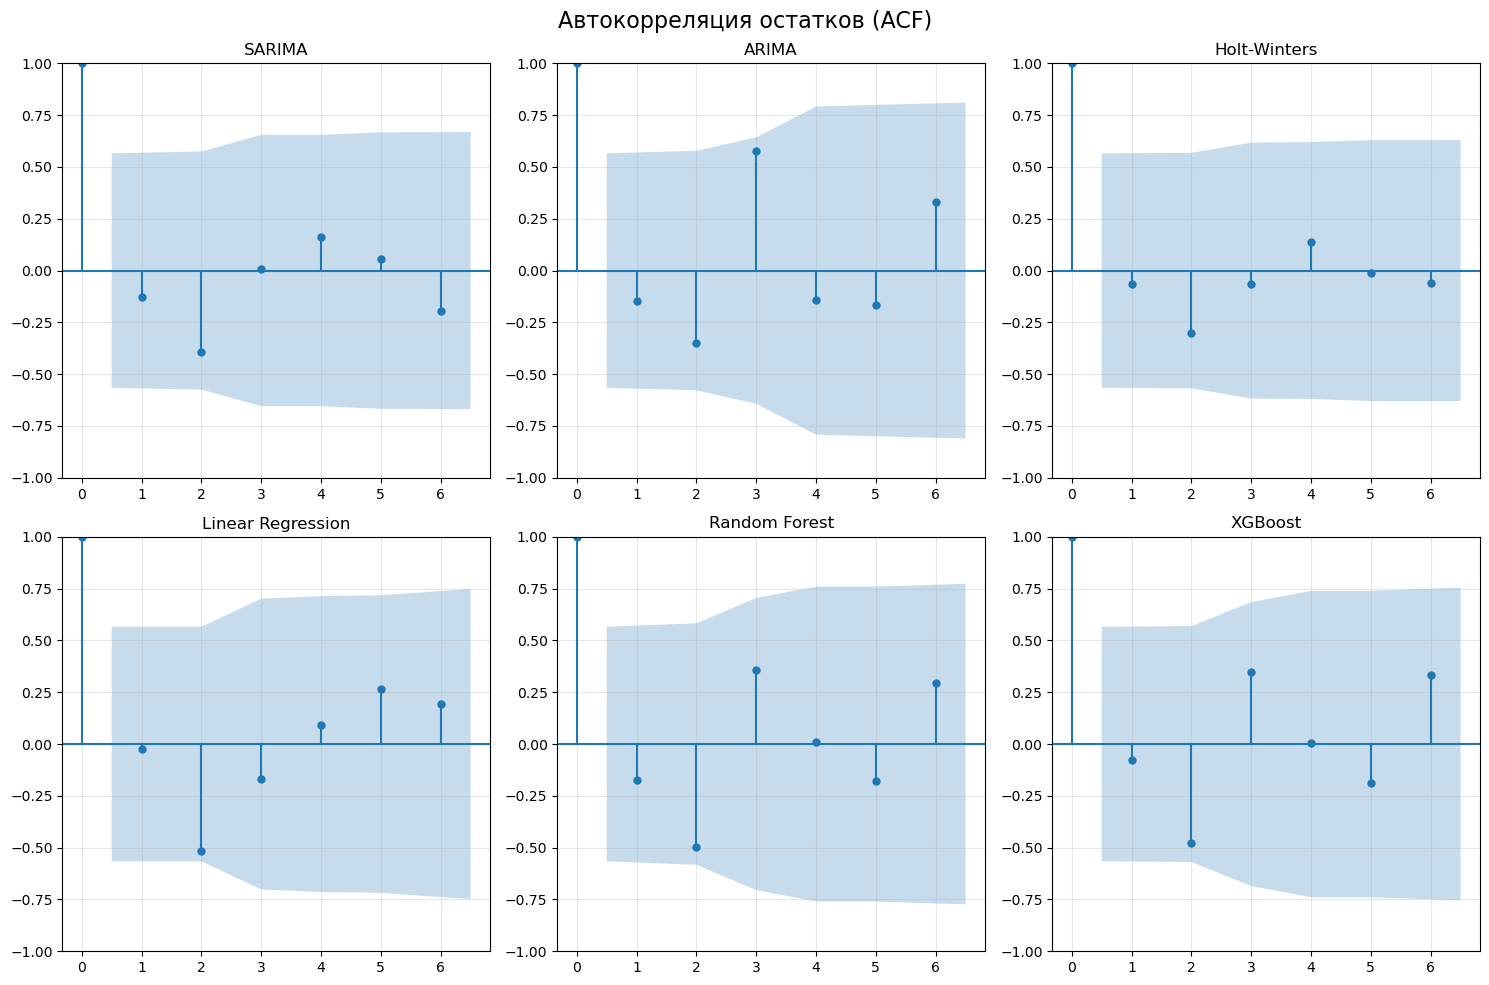

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Автокорреляция остатков (ACF)', fontsize=16)

from statsmodels.graphics.tsaplots import plot_acf

for idx, model_name in enumerate(model_names):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    residuals = residuals_dict[model_name]
    
    plot_acf(residuals, lags=min(20, len(residuals)//2), ax=ax, alpha=0.05)
    ax.set_title(f'{model_name}')
    ax.grid(True, alpha=0.3)

for idx in range(len(model_names), 6):
    row = idx // 3
    col = idx % 3
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

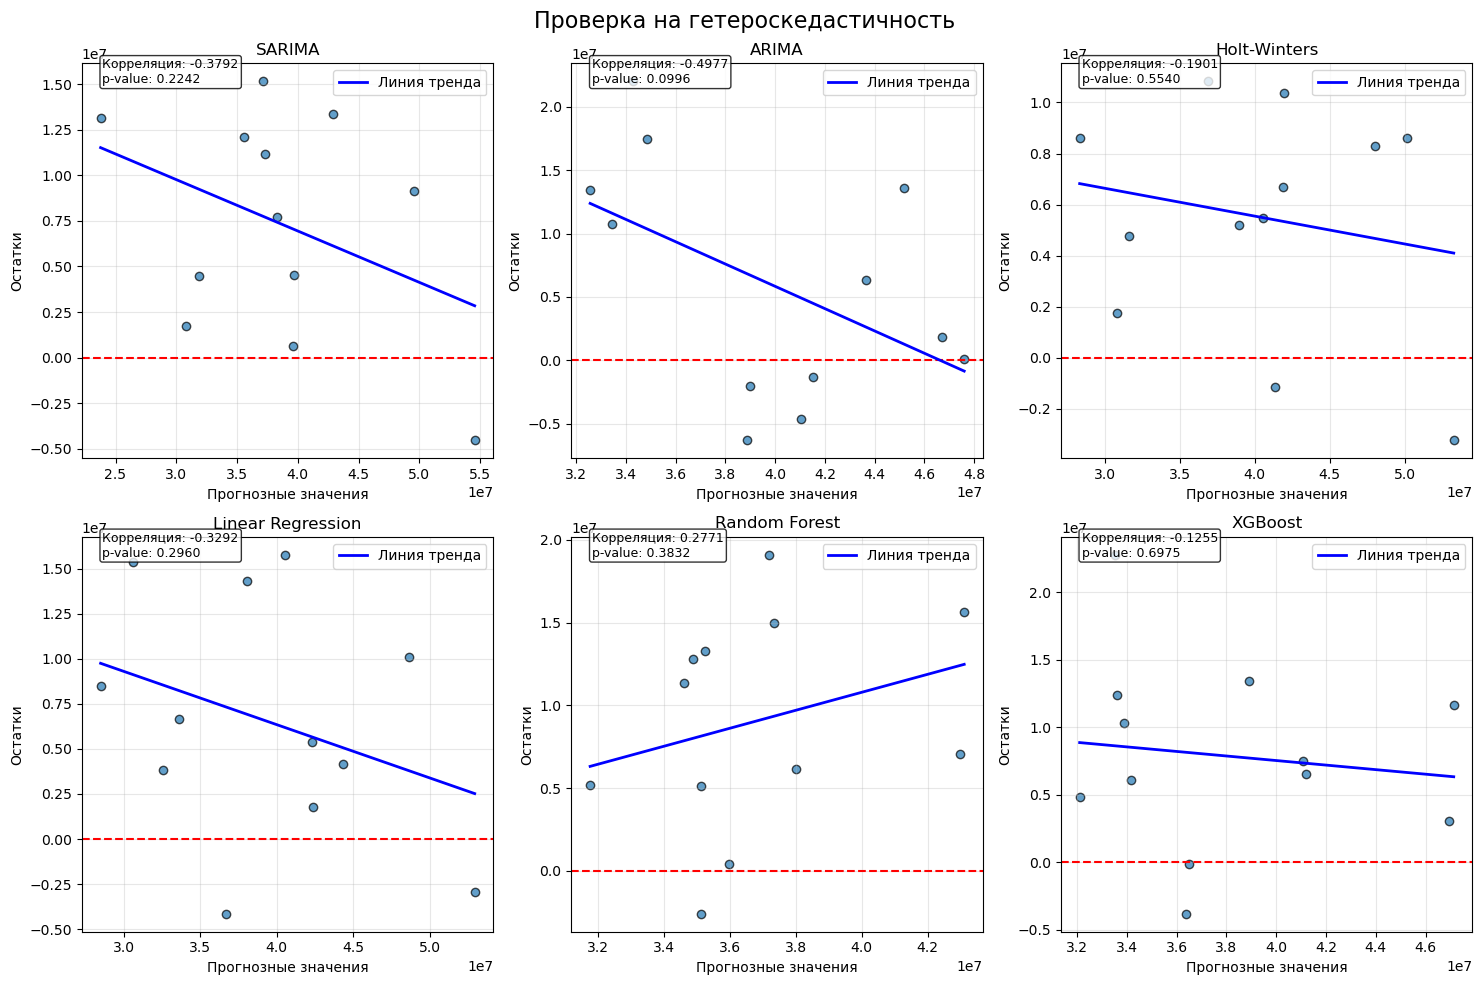

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Проверка на гетероскедастичность', fontsize=16)

from scipy.stats import pearsonr

for idx, model_name in enumerate(model_names):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    residuals = residuals_dict[model_name]
    predicted = results_df[model_name]
    
    ax.scatter(predicted, residuals, alpha=0.7, edgecolors='black')
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
    
    z = np.polyfit(predicted, residuals, 1)
    p = np.poly1d(z)
    ax.plot(sorted(predicted), p(sorted(predicted)), "b-", linewidth=2, label='Линия тренда')
    
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Прогнозные значения')
    ax.set_ylabel('Остатки')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    corr, p_value = pearsonr(predicted, residuals)
    ax.text(0.05, 0.95, f'Корреляция: {corr:.4f}\np-value: {p_value:.4f}', 
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

for idx in range(len(model_names), 6):
    row = idx // 3
    col = idx % 3
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()


In [54]:
residuals_stats = []
for model_name in model_names:
    residuals = residuals_dict[model_name]
    
    stats_dict = {
        'Модель': model_name,
        'Среднее': residuals.mean(),
        'Стд. отклонение': residuals.std(),
        'Медиана': residuals.median(),
        'Мин': residuals.min(),
        'Макс': residuals.max(),
      #  'Асимметрия': residuals.skew(),
       # 'Эксцесс': residuals.kurtosis(),
        'Дисперсия': residuals.var()
    }
    
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals)
    stats_dict['Дарбин-Уотсон'] = dw
    
    if len(residuals) < 5000:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
        stats_dict['Shapiro p-value'] = shapiro_p
    
    residuals_stats.append(stats_dict)

residuals_df = pd.DataFrame(residuals_stats)
residuals_df = residuals_df.round(4)
print(residuals_df.to_string(index=False))

           Модель      Среднее  Стд. отклонение      Медиана           Мин         Макс    Дисперсия  Дарбин-Уотсон  Shapiro p-value
           SARIMA 7388580.9677     6073916.8588 8425528.2857 -4.532799e+06 1.515912e+07 3.689247e+13         0.7742           0.5454
            ARIMA 5934019.4242     9341836.7907 4082659.8970 -6.319514e+06 2.202462e+07 8.726991e+13         1.3900           0.4759
     Holt-Winters 5514202.4610     4426253.3652 6071434.2431 -3.230992e+06 1.082951e+07 1.959172e+13         0.7238           0.2675
Linear Regression 6562529.9231     6611822.5016 6031335.6660 -4.141927e+06 1.576291e+07 4.371620e+13         0.8124           0.6225
    Random Forest 9038256.8441     6544882.3328 9204182.5308 -2.592889e+06 1.909811e+07 4.283548e+13         0.6450           0.8351
          XGBoost 7872065.3793     6948187.1937 6977318.8845 -3.824770e+06 2.276821e+07 4.827731e+13         0.7674           0.9456
